# Phase 4: Tabular Methods Comparison

## Objective
Compare four classical tabular RL algorithms on the min-steps Mountain Car scenario,
using the optimal 20×20 discretization identified in Phase 2.

## Algorithms

| Algorithm | Family | Update rule | Exploration |
|-----------|--------|-------------|-------------|
| **Q-Learning** | Off-policy TD | Q[s,a] ← Q[s,a] + α(r + γ max Q[s',·] − Q[s,a]) | ε-greedy |
| **SARSA** | On-policy TD | Q[s,a] ← Q[s,a] + α(r + γ Q[s',a'] − Q[s,a]) | ε-greedy |
| **MC Every-Visit** | On-policy MC | Q[s,a] ← Q[s,a] + α(G_t − Q[s,a]) for every (s,a) visit | ε-greedy |
| **MC First-Visit** | On-policy MC | Q[s,a] ← Q[s,a] + α(G_t − Q[s,a]) only at first visit of (s,a) | ε-greedy |

### Key distinctions

**TD vs Monte Carlo**: TD methods (Q-Learning, SARSA) update at every step using a
bootstrapped estimate of future value. MC methods wait until the episode ends, then
update using the actual discounted return G_t — no bootstrapping, but also no
per-step signal.

**Every-Visit vs First-Visit MC**: In a single episode, the same state-action pair
may appear multiple times. Every-visit MC updates Q(s,a) at every occurrence, using
each occurrence's own return G_t. First-visit MC updates Q(s,a) only at the *first*
occurrence in the episode (lowest t), ignoring later revisits. First-visit is
theoretically unbiased; every-visit has lower variance in practice.

**Off-policy vs On-policy TD**: Q-Learning bootstraps from max_a Q(s',a) — the
value of the *best* action, regardless of what the agent actually does. SARSA
bootstraps from Q(s', a') where a' is the actual next action sampled from the
exploratory policy. Q-Learning targets the optimal value; SARSA targets the value
of the policy currently being followed.

## Experimental Design
- Environment: `MountainCar-v0`, min-steps reward (−1 per step)
- Discretization: **20×20 bins** (optimal from Phase 2)
- Seeds: 5 per method
- Episodes: 5 000 per seed
- Hyperparameters: α=0.1, γ=0.99, ε_start=1.0, ε_decay=0.995, ε_min=0.05


## Setup: Imports and Monte Carlo Implementations

Q-Learning and SARSA are imported from `src`. Both MC variants are defined
inline — the `MonteCarloAgent` in `src` has a broken constructor.

### Every-Visit MC
Updates Q(s,a) for **every occurrence** of (s,a) in the episode during the
backward sweep. Each occurrence uses its own G_t (return from that timestep
to the end of the episode).

### First-Visit MC
Pre-computes the **first occurrence index** of each (s,a) pair with a forward
pass over the episode. Then during the backward sweep, only updates Q(s,a) when
the current timestep t equals that first occurrence index. All later revisits
in the same episode are skipped.


In [38]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iterproduct

root_path = os.path.abspath("..")
if root_path not in sys.path:
    sys.path.append(root_path)

from src.environment_utils import create_env, StateDiscretizer
from src.agents.tabular_agents import QLearning, SARSA
from src.evaluation import train_agent, StatisticalAnalyzer, _extract_training_lists
from src.plotting import plot_policy_map, plot_visitation_heatmap


# ── Shared base for both MC variants ────────────────────────────────────────
class _MCBase:
    def __init__(self, n_pos_bins=10, n_vel_bins=10, n_actions=3,
                 alpha=0.1, gamma=0.99,
                 epsilon_start=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.discretizer   = StateDiscretizer(n_pos_bins, n_vel_bins)
        self.Q             = np.zeros((n_pos_bins, n_vel_bins, n_actions), dtype=np.float64)
        self.visit_counts  = np.zeros((n_pos_bins, n_vel_bins), dtype=np.int32)

    def select_action(self, state):
        """ε-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        s = self.discretizer.discretize(state)
        return int(np.argmax(self.Q[s]))

    def act(self, state, training=False):
        """Greedy action for evaluation."""
        s = self.discretizer.discretize(state)
        return int(np.argmax(self.Q[s]))

    def _decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# ── Every-Visit MC ───────────────────────────────────────────────────────────
class MonteCarloEveryVisit(_MCBase):
    """
    On-policy every-visit MC control.
    Updates Q(s,a) for EVERY occurrence of (s,a) in the episode.
    Backward sweep: G accumulates correctly for each timestep's return.
    """
    def update_from_episode(self, states, actions, rewards):
        G = 0.0
        for t in reversed(range(len(rewards))):
            G = rewards[t] + self.gamma * G
            s, a = states[t], actions[t]
            self.visit_counts[s] += 1
            self.Q[s + (a,)] += self.alpha * (G - self.Q[s + (a,)])
        self._decay_epsilon()


# ── First-Visit MC ───────────────────────────────────────────────────────────
class MonteCarloFirstVisit(_MCBase):
    """
    On-policy first-visit MC control.
    Updates Q(s,a) only at the FIRST occurrence of (s,a) in the episode.

    Implementation:
    1. Forward pass: record the first occurrence index for each (s,a) pair.
    2. Backward sweep: compute G_t; update only when t == first_occurrence[s,a].
    """
    def update_from_episode(self, states, actions, rewards):
        # Step 1 — forward pass: find first occurrence of each (s,a)
        first_occ = {}
        for t in range(len(states)):
            sa = states[t] + (actions[t],)
            if sa not in first_occ:
                first_occ[sa] = t

        # Step 2 — backward sweep: update only at first occurrence
        G = 0.0
        for t in reversed(range(len(rewards))):
            G = rewards[t] + self.gamma * G
            s, a = states[t], actions[t]
            sa   = s + (a,)
            if first_occ[sa] == t:          # first-visit check
                self.visit_counts[s] += 1
                self.Q[sa] += self.alpha * (G - self.Q[sa])
        self._decay_epsilon()


# ── Shared MC training loop ──────────────────────────────────────────────────
def train_mc(agent, env, n_episodes, seed=0):
    """Training loop for any MC agent (needs full episodes before update)."""
    np.random.seed(seed)
    rewards, successes, steps = [], [], []

    for _ in range(n_episodes):
        state, _                        = env.reset()
        ep_states, ep_actions, ep_rews  = [], [], []
        success                         = False

        while True:
            action  = agent.select_action(state)
            s_disc  = agent.discretizer.discretize(state)
            next_s, reward, term, trunc, _ = env.step(action)
            done    = term or trunc

            ep_states.append(s_disc)
            ep_actions.append(action)
            ep_rews.append(reward)
            if term:
                success = True
            state = next_s
            if done:
                break

        agent.update_from_episode(ep_states, ep_actions, ep_rews)
        rewards.append(sum(ep_rews))
        successes.append(int(success))
        steps.append(len(ep_rews))

    return rewards, successes, steps


print("✓ All agents defined: QLearning, SARSA, MonteCarloEveryVisit, MonteCarloFirstVisit")


✓ All agents defined: QLearning, SARSA, MonteCarloEveryVisit, MonteCarloFirstVisit


## Configuration

In [39]:
N_BINS        = 20
N_EPISODES    = 5_000
N_SEEDS       = 5
ALPHA         = 0.1
GAMMA         = 0.99
EPSILON_DECAY = 0.995
EPSILON_MIN   = 0.05

METHODS = ["Q-Learning", "SARSA", "MC Every-Visit", "MC First-Visit"]
METHOD_COLORS = {
    "Q-Learning":    "#2E86AB",
    "SARSA":         "#F18F01",
    "MC Every-Visit":"#A23B72",
    "MC First-Visit":"#3BB273",
}

print(f"Discretization : {N_BINS}×{N_BINS}  |  Episodes : {N_EPISODES}  |  Seeds : {N_SEEDS}")
print(f"α={ALPHA}  γ={GAMMA}  ε_decay={EPSILON_DECAY}  ε_min={EPSILON_MIN}")


Discretization : 20×20  |  Episodes : 5000  |  Seeds : 5
α=0.1  γ=0.99  ε_decay=0.995  ε_min=0.05


## Part 1 — Head-to-Head Comparison

All four methods trained with identical hyperparameters on the min-steps scenario.
MC methods use the same ε-greedy exploration as Q-Learning and SARSA (not exploring
starts), so the only difference is the update rule.


In [40]:
results = {m: {"rewards": [], "successes": [], "steps": [],
               "q_tables": [], "visits": [], "action_counts": []}
           for m in METHODS}

for seed in range(N_SEEDS):
    print(f"\n── Seed {seed+1}/{N_SEEDS} " + "─"*40)

    # ── Q-Learning ──────────────────────────────────────────────────────────
    env      = create_env("discrete", "min_steps", seed=seed)
    agent_ql = QLearning(n_pos_bins=N_BINS, n_vel_bins=N_BINS, alpha=ALPHA,
                         gamma=GAMMA, epsilon_decay=EPSILON_DECAY, epsilon_min=EPSILON_MIN)
    t0       = time.time()
    m, _     = train_agent(agent_ql, env, n_episodes=N_EPISODES, seed=seed, verbose=False)
    rews_ql, succs_ql, stps_ql = _extract_training_lists(m)
    env.close()
    print(f"  Q-Learning      SR(last 100)={np.mean(succs_ql[-100:]):.1%}  t={time.time()-t0:.1f}s")

    # ── SARSA ────────────────────────────────────────────────────────────────
    env      = create_env("discrete", "min_steps", seed=seed)
    agent_sa = SARSA(n_pos_bins=N_BINS, n_vel_bins=N_BINS, alpha=ALPHA,
                     gamma=GAMMA, epsilon_decay=EPSILON_DECAY, epsilon_min=EPSILON_MIN)
    t0       = time.time()
    m, _     = train_agent(agent_sa, env, n_episodes=N_EPISODES, seed=seed, verbose=False)
    rews_sa, succs_sa, stps_sa = _extract_training_lists(m)
    env.close()
    print(f"  SARSA           SR(last 100)={np.mean(succs_sa[-100:]):.1%}  t={time.time()-t0:.1f}s")

    # ── MC Every-Visit ───────────────────────────────────────────────────────
    env      = create_env("discrete", "min_steps", seed=seed)
    agent_ev = MonteCarloEveryVisit(n_pos_bins=N_BINS, n_vel_bins=N_BINS, alpha=ALPHA,
                                    gamma=GAMMA, epsilon_decay=EPSILON_DECAY,
                                    epsilon_min=EPSILON_MIN)
    t0       = time.time()
    rews_ev, succs_ev, stps_ev = train_mc(agent_ev, env, n_episodes=N_EPISODES, seed=seed)
    env.close()
    print(f"  MC Every-Visit  SR(last 100)={np.mean(succs_ev[-100:]):.1%}  t={time.time()-t0:.1f}s")

    # ── MC First-Visit ───────────────────────────────────────────────────────
    env      = create_env("discrete", "min_steps", seed=seed)
    agent_fv = MonteCarloFirstVisit(n_pos_bins=N_BINS, n_vel_bins=N_BINS, alpha=ALPHA,
                                    gamma=GAMMA, epsilon_decay=EPSILON_DECAY,
                                    epsilon_min=EPSILON_MIN)
    t0       = time.time()
    rews_fv, succs_fv, stps_fv = train_mc(agent_fv, env, n_episodes=N_EPISODES, seed=seed)
    env.close()
    print(f"  MC First-Visit  SR(last 100)={np.mean(succs_fv[-100:]):.1%}  t={time.time()-t0:.1f}s")

    # ── Greedy action distribution (50 eval episodes) ───────────────────────
    for method, agent in [("Q-Learning",    agent_ql),
                          ("SARSA",         agent_sa),
                          ("MC Every-Visit",agent_ev),
                          ("MC First-Visit",agent_fv)]:
        ac = np.zeros(3, dtype=np.int64)
        env_e = create_env("discrete", "min_steps", seed=seed + 100)
        for _ in range(50):
            s, _ = env_e.reset()
            done = False
            while not done:
                a = agent.act(s)
                ac[a] += 1
                s, _, term, trunc, _ = env_e.step(a)
                done = term or trunc
        env_e.close()

        rw = {"Q-Learning": rews_ql, "SARSA": rews_sa,
              "MC Every-Visit": rews_ev, "MC First-Visit": rews_fv}[method]
        sc = {"Q-Learning": succs_ql, "SARSA": succs_sa,
              "MC Every-Visit": succs_ev, "MC First-Visit": succs_fv}[method]
        st = {"Q-Learning": stps_ql, "SARSA": stps_sa,
              "MC Every-Visit": stps_ev, "MC First-Visit": stps_fv}[method]
        ag = {"Q-Learning": agent_ql, "SARSA": agent_sa,
              "MC Every-Visit": agent_ev, "MC First-Visit": agent_fv}[method]

        results[method]["rewards"].append(rw)
        results[method]["successes"].append(sc)
        results[method]["steps"].append(st)
        results[method]["q_tables"].append(ag.Q.copy())
        results[method]["visits"].append(ag.visit_counts.copy())
        results[method]["action_counts"].append(ac)

print("\n✓ Training complete")



── Seed 1/5 ────────────────────────────────────────
  Q-Learning      SR(last 100)=94.0%  t=30.2s
  SARSA           SR(last 100)=83.0%  t=30.8s
  MC Every-Visit  SR(last 100)=0.0%  t=23.0s
  MC First-Visit  SR(last 100)=0.0%  t=22.2s

── Seed 2/5 ────────────────────────────────────────
  Q-Learning      SR(last 100)=81.0%  t=30.8s
  SARSA           SR(last 100)=68.0%  t=30.2s
  MC Every-Visit  SR(last 100)=0.0%  t=22.2s
  MC First-Visit  SR(last 100)=0.0%  t=22.3s

── Seed 3/5 ────────────────────────────────────────
  Q-Learning      SR(last 100)=89.0%  t=31.5s
  SARSA           SR(last 100)=73.0%  t=30.4s
  MC Every-Visit  SR(last 100)=0.0%  t=22.2s
  MC First-Visit  SR(last 100)=0.0%  t=21.0s

── Seed 4/5 ────────────────────────────────────────
  Q-Learning      SR(last 100)=81.0%  t=27.7s
  SARSA           SR(last 100)=13.0%  t=27.6s
  MC Every-Visit  SR(last 100)=0.0%  t=21.0s
  MC First-Visit  SR(last 100)=0.0%  t=20.6s

── Seed 5/5 ────────────────────────────────────────
  

### Learning Curves

The plots below show episode reward (smoothed with a 100-episode moving average),
success rate, and steps per episode across all four methods.

**What bootstrapping buys**: TD methods (Q-Learning, SARSA) receive a value signal
at every step — even in failed episodes — because each step's update uses the
current Q-table as a proxy for future value. MC methods must wait for the episode
to terminate, then propagate the final return backward. In Mountain Car, where most
early episodes end by truncation at 200 steps, TD methods accumulate useful
gradient updates thousands of times before MC methods receive their first signal.

**Every-visit vs first-visit MC**: In a 200-step episode, states near the valley
floor are visited hundreds of times. Every-visit MC updates Q(s,a) each time,
using the return G_t computed from that specific timestep. First-visit MC updates
only once — using the return from the *earliest* visit, which has the longest
time horizon and therefore the strongest discounting. In practice, first-visit MC
produces lower-variance updates because it avoids the correlation between multiple
G_t estimates from the same state within one episode.


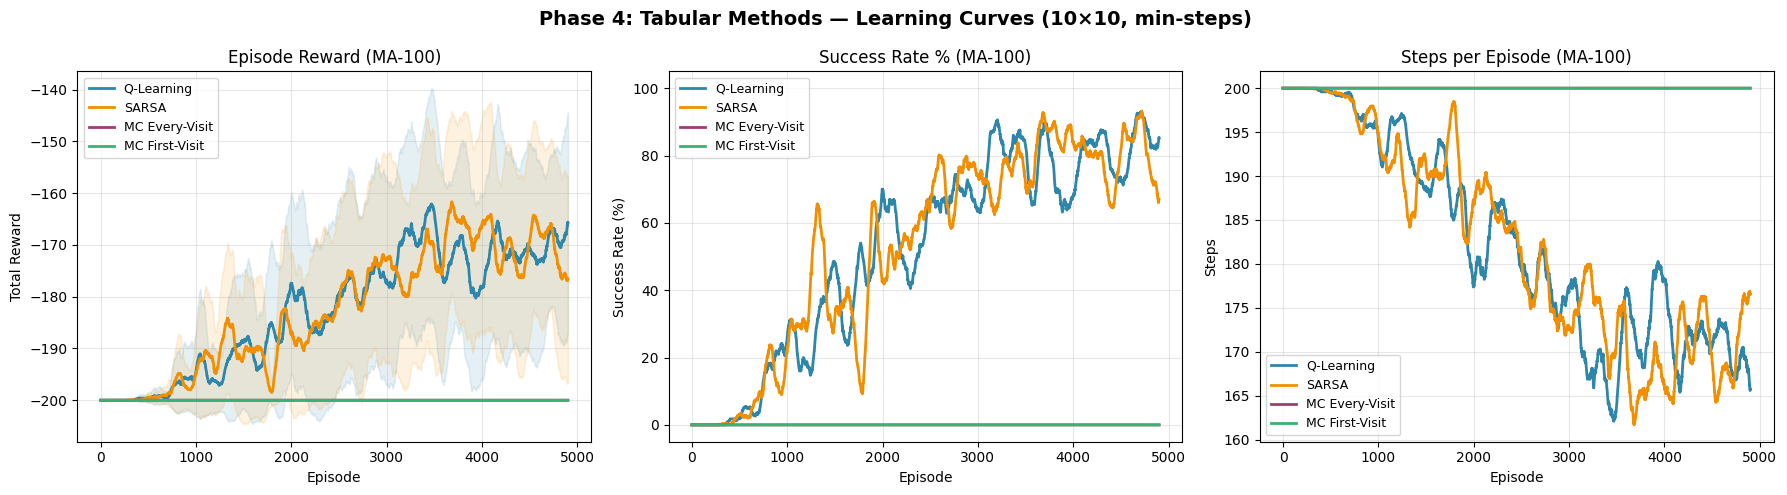

Saved: phase4_learning_curves.png


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
W = 100

for method, color in METHOD_COLORS.items():
    mean_r  = np.mean(results[method]["rewards"],   axis=0)
    std_r   = np.std(results[method]["rewards"],    axis=0)
    mean_s  = np.mean(results[method]["successes"], axis=0)
    mean_st = np.mean(results[method]["steps"],     axis=0)

    def sm(x): return np.convolve(np.asarray(x, float), np.ones(W)/W, "valid")

    ep = np.arange(len(sm(mean_r)))
    axes[0].plot(ep, sm(mean_r), color=color, label=method, linewidth=2)
    axes[0].fill_between(ep, sm(mean_r - std_r), sm(mean_r + std_r),
                         color=color, alpha=0.12)
    axes[1].plot(np.arange(len(sm(mean_s))),  sm(mean_s) * 100,
                 color=color, label=method, linewidth=2)
    axes[2].plot(np.arange(len(sm(mean_st))), sm(mean_st),
                 color=color, label=method, linewidth=2)

for ax, title, ylabel in zip(axes,
    ["Episode Reward (MA-100)", "Success Rate % (MA-100)", "Steps per Episode (MA-100)"],
    ["Total Reward", "Success Rate (%)", "Steps"]):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Episode")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
axes[1].set_ylim(-5, 105)

plt.suptitle("Phase 4: Tabular Methods — Learning Curves (10×10, min-steps)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("phase4_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase4_learning_curves.png")


### Performance Summary Table

In [42]:
rows = []
for method in METHODS:
    succ_arr = np.array(results[method]["successes"])
    step_arr = np.array(results[method]["steps"])
    rew_arr  = np.array(results[method]["rewards"])
    ac_arr   = np.array(results[method]["action_counts"])

    sr  = succ_arr[:, -200:].mean(axis=1)
    st  = step_arr[:, -200:].mean(axis=1)
    rew = rew_arr[:,  -200:].mean(axis=1)
    tot = ac_arr.sum(axis=1)
    thr = (ac_arr[:, 0] + ac_arr[:, 2]) / tot

    first_success = []
    for seed_s in succ_arr:
        ma  = np.convolve(seed_s.astype(float), np.ones(100) / 100, "valid")
        idx = np.argmax(ma >= 0.10)
        first_success.append(int(idx + 100) if ma[idx] >= 0.10 else N_EPISODES)

    rows.append({
        "Method":            method,
        "Success Rate":      f"{sr.mean()*100:.1f}% ± {sr.std()*100:.1f}%",
        "Avg Steps":         f"{st.mean():.1f} ± {st.std():.1f}",
        "Avg Reward":        f"{rew.mean():.1f} ± {rew.std():.1f}",
        "First 10% SR (ep)": f"{np.mean(first_success):.0f} ± {np.std(first_success):.0f}",
        "Thrust Rate":       f"{thr.mean()*100:.1f}%",
    })

df = pd.DataFrame(rows)
print("\nPHASE 4 — METHOD COMPARISON (Min-Steps, 10×10 bins, 5 seeds)")
print("=" * 110)
print(df.to_string(index=False))
print("=" * 110)



PHASE 4 — METHOD COMPARISON (Min-Steps, 10×10 bins, 5 seeds)
        Method  Success Rate   Avg Steps   Avg Reward First 10% SR (ep) Thrust Rate
    Q-Learning  85.3% ± 4.3% 167.6 ± 4.5 -167.6 ± 4.5          810 ± 87       82.0%
         SARSA 71.8% ± 18.6% 175.4 ± 4.8 -175.4 ± 4.8          808 ± 53       83.4%
MC Every-Visit   0.0% ± 0.0% 200.0 ± 0.0 -200.0 ± 0.0          5000 ± 0       89.6%
MC First-Visit   0.0% ± 0.0% 200.0 ± 0.0 -200.0 ± 0.0          5000 ± 0       66.1%


### Policy Visualization

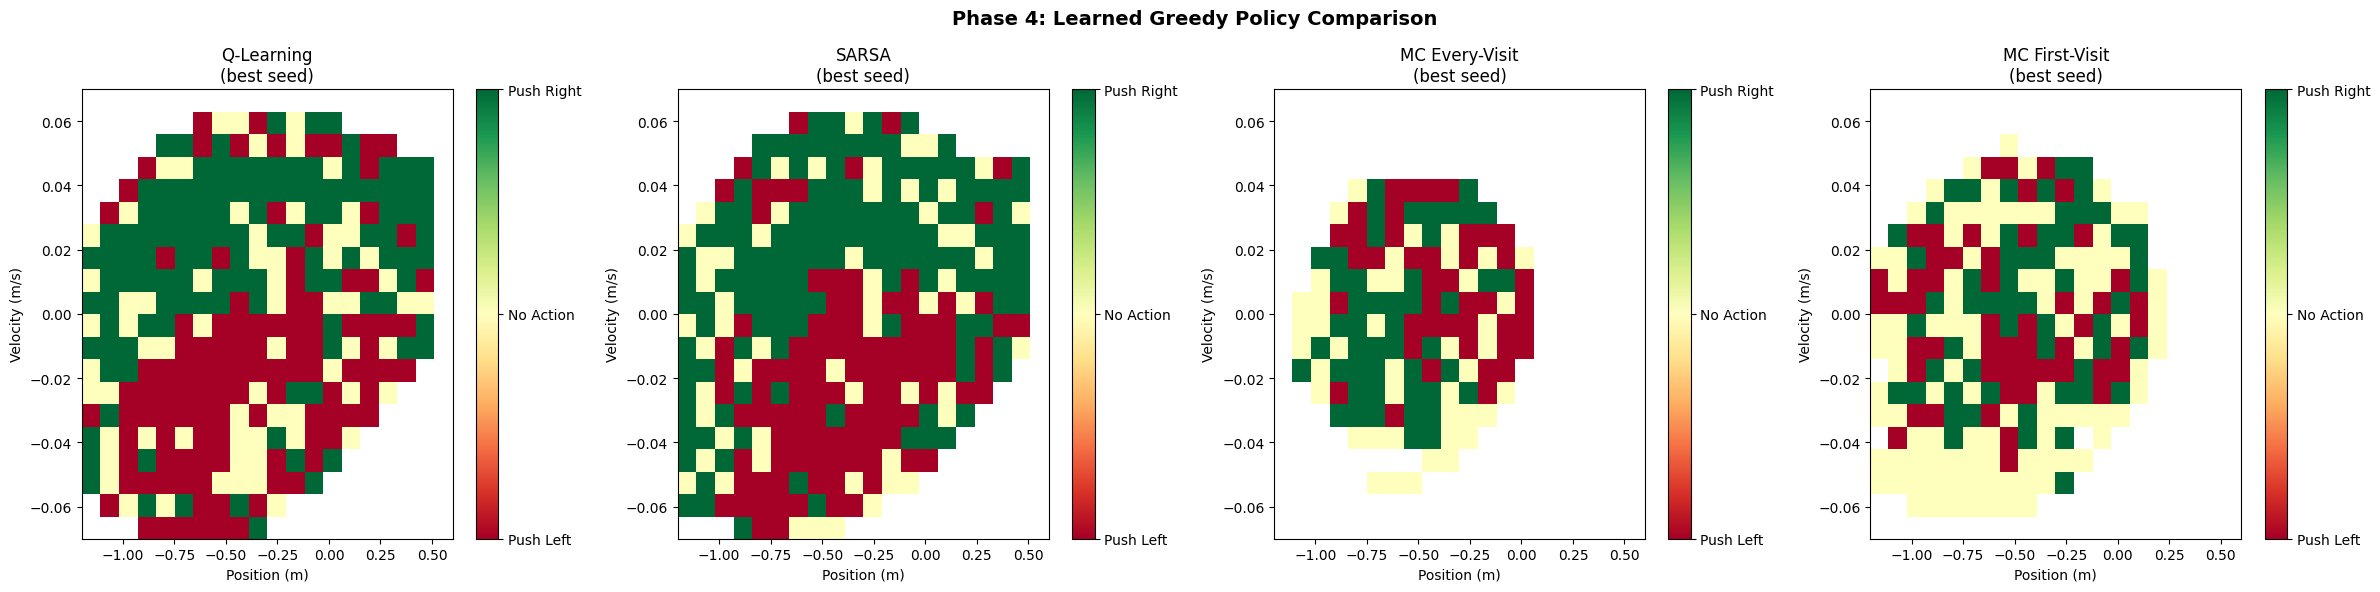

Saved: phase4_policies.png


In [43]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, method in zip(axes, METHODS):
    best = int(np.argmax([np.mean(s[-200:]) for s in results[method]["successes"]]))
    plot_policy_map(
        results[method]["q_tables"][best],
        StateDiscretizer(N_BINS, N_BINS),
        visit_counts=results[method]["visits"][best],
        mask_unvisited=True,
        title=f"{method}\n(best seed)",
        ax=ax,
    )

plt.suptitle("Phase 4: Learned Greedy Policy Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("phase4_policies.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase4_policies.png")


### State Visitation Heatmaps

State visitation reveals how broadly each algorithm explored the space.

A converged Mountain Car agent must visit the high-velocity regions near the
hilltops — only there does the momentum-building strategy become visible. Methods
that never explore those regions are unlikely to converge.

TD methods can "seed" value into unvisited regions through bootstrapping: a state
adjacent to a well-valued state inherits value without being visited itself. MC
methods have no such mechanism — Q(s,a) remains at its initial value (0) for any
(s,a) that was never visited during training. Sparse visitation directly limits
what MC can learn.


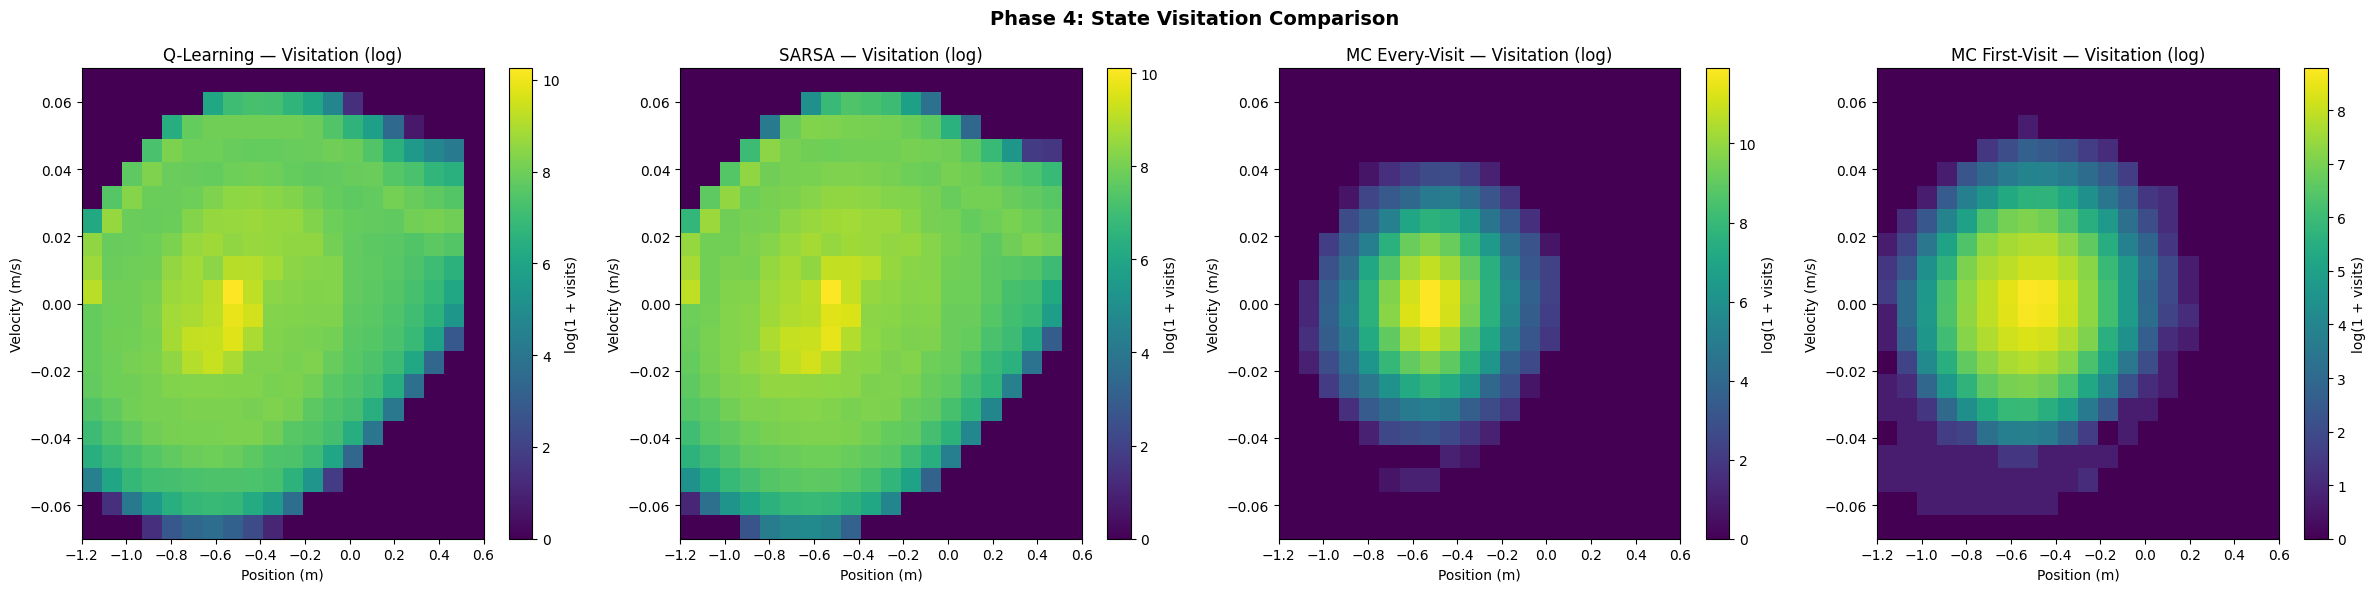

Saved: phase4_visitation.png


In [44]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, method in zip(axes, METHODS):
    best = int(np.argmax([np.mean(s[-200:]) for s in results[method]["successes"]]))
    plot_visitation_heatmap(
        results[method]["visits"][best],
        StateDiscretizer(N_BINS, N_BINS),
        log_scale=True,
        title=f"{method} — Visitation (log)",
        ax=ax,
    )

plt.suptitle("Phase 4: State Visitation Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("phase4_visitation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase4_visitation.png")


### Per-Seed Success Rate

A method with high mean success but high seed variance is unreliable in practice.
Mountain Car's sparse reward turns the early exploration phase into a lottery:
the seed determines whether a random walk accidentally reaches the goal within the
first few hundred episodes. Methods that can learn even without an early lucky
discovery tend to have lower variance.


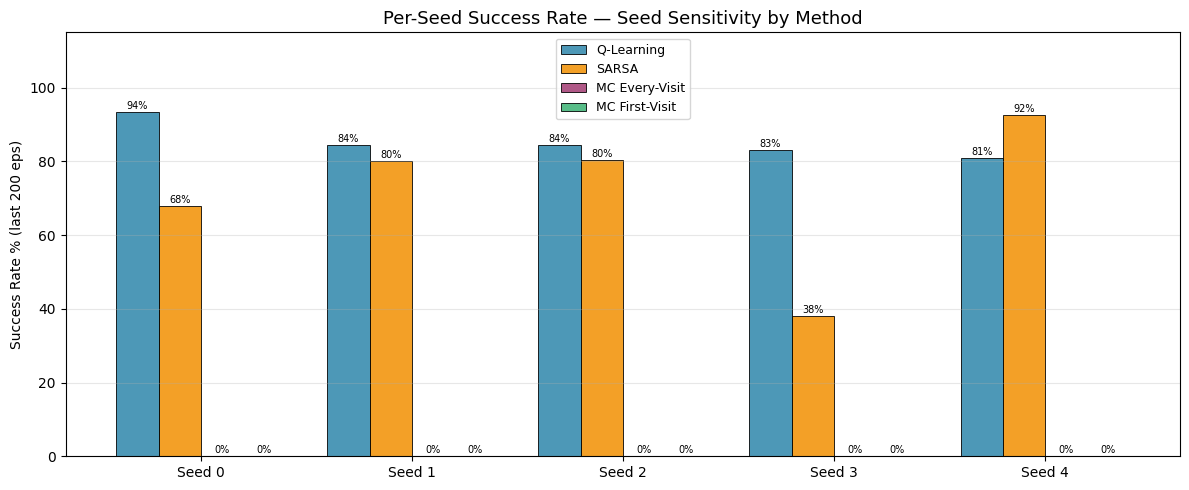

Saved: phase4_seed_variance.png


In [45]:
fig, ax = plt.subplots(figsize=(12, 5))

x       = np.arange(N_SEEDS)
width   = 0.2
offsets = np.linspace(-1.5 * width, 1.5 * width, len(METHODS))

for i, (method, color) in enumerate(METHOD_COLORS.items()):
    per_seed = [np.mean(s[-200:]) * 100 for s in results[method]["successes"]]
    bars = ax.bar(x + offsets[i], per_seed, width=width,
                  color=color, alpha=0.85, edgecolor="black", linewidth=0.7,
                  label=method)
    for bar, val in zip(bars, per_seed):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{val:.0f}%", ha="center", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f"Seed {i}" for i in range(N_SEEDS)])
ax.set_ylabel("Success Rate % (last 200 eps)")
ax.set_title("Per-Seed Success Rate — Seed Sensitivity by Method", fontsize=13)
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("phase4_seed_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase4_seed_variance.png")


## Statistical Analysis

In [46]:
print("STATISTICAL ANALYSIS")
print("=" * 65)
for method in METHODS:
    all_rews = np.array(results[method]["rewards"])
    mean_rew = all_rews.mean(axis=0)
    ci_lo, ci_hi = StatisticalAnalyzer.compute_confidence_interval(
        all_rews.flatten(), confidence=0.95)
    conv = StatisticalAnalyzer.compute_convergence_metrics(
        mean_rew.tolist(), window_size=100)
    sr_per_seed = [np.mean(s[-200:]) for s in results[method]["successes"]]

    print(f"\n{method}")
    print(f"  Success rate          : {np.mean(sr_per_seed)*100:.1f}% ± {np.std(sr_per_seed)*100:.1f}%")
    print(f"  95% CI reward         : [{ci_lo:.1f}, {ci_hi:.1f}]")
    print(f"  Improvement score     : {conv['improvement']:.2f}")
    print(f"  Stability score       : {conv['stability_score']:.3f}")
    print(f"  Final window mean rew : {conv['final_window_mean']:.2f}")

print("\n✓ Analysis complete")


STATISTICAL ANALYSIS

Q-Learning
  Success rate          : 85.3% ± 4.3%
  95% CI reward         : [-182.9, -182.3]
  Improvement score     : 33.80
  Stability score       : 0.363
  Final window mean rew : -166.20

SARSA
  Success rate          : 71.8% ± 18.6%
  95% CI reward         : [-183.0, -182.5]
  Improvement score     : 23.31
  Stability score       : 0.128
  Final window mean rew : -176.69

MC Every-Visit
  Success rate          : 0.0% ± 0.0%
  95% CI reward         : [-200.0, -200.0]
  Improvement score     : 0.00
  Stability score       : 0.000
  Final window mean rew : -200.00

MC First-Visit
  Success rate          : 0.0% ± 0.0%
  95% CI reward         : [-200.0, -200.0]
  Improvement score     : 0.00
  Stability score       : 0.000
  Final window mean rew : -200.00

✓ Analysis complete


## Part 2 — Hyperparameter Sensitivity

We sweep three hyperparameters for Q-Learning and SARSA (MC methods are excluded
if they failed to converge in Part 1):

| Parameter | Values tested | What it controls |
|-----------|--------------|-----------------|
| **α** (learning rate) | {0.05, 0.1, 0.2} | Step size of each Q-update |
| **γ** (discount factor) | {0.95, 0.99} | Planning horizon — how far-sighted the agent is |
| **ε_decay** | {0.995, 0.999} | How quickly exploration gives way to exploitation |

→ 3 × 2 × 2 = **12 configurations** per method × 3 seeds × 2 000 episodes

**Why γ matters critically here**: Mountain Car episodes can last up to 200 steps.
With γ=0.95, the return from reaching the goal after 150 steps is discounted by
0.95¹⁵⁰ ≈ 0.0006 — effectively zero. The agent becomes near-sighted and learns
no useful behaviour. With γ=0.99, the same discounting is 0.99¹⁵⁰ ≈ 0.22 — still
meaningful. We expect γ=0.99 to dominate overwhelmingly.

**ε_decay tradeoff**: A fast decay (0.995, reaches ε_min≈0.05 after ~580 episodes)
means the agent commits to exploitation early. If the goal was found before episode
580, this accelerates convergence. If not, the agent locks into a bad greedy policy.
Slow decay (0.999, reaches ε_min after ~2 995 episodes) keeps exploration alive
longer — more robust, but potentially slower to exploit good discoveries.


In [52]:
HP_ALPHAS   = [0.05, 0.1, 0.2]
HP_GAMMAS   = [0.95, 0.99]
HP_EDECAYS  = [0.995, 0.999]
HP_SEEDS    = 5
HP_EPISODES = 5_000
HP_METHODS  = ["Q-Learning", "SARSA"]

hp_results  = {m: {} for m in HP_METHODS}
total_runs  = len(HP_ALPHAS) * len(HP_GAMMAS) * len(HP_EDECAYS) * len(HP_METHODS) * HP_SEEDS
done        = 0

print(f"Grid: {len(HP_ALPHAS)}α × {len(HP_GAMMAS)}γ × {len(HP_EDECAYS)}ε_d "
      f"× {len(HP_METHODS)} methods × {HP_SEEDS} seeds = {total_runs} runs\n")

for alpha, gamma, edecay in iterproduct(HP_ALPHAS, HP_GAMMAS, HP_EDECAYS):
    cfg = (alpha, gamma, edecay)
    for method in HP_METHODS:
        seed_srs = []
        for seed in range(HP_SEEDS):
            env = create_env("discrete", "min_steps", seed=seed)
            if method == "Q-Learning":
                agent = QLearning(n_pos_bins=N_BINS, n_vel_bins=N_BINS,
                                  alpha=alpha, gamma=gamma,
                                  epsilon_decay=edecay, epsilon_min=EPSILON_MIN)
            else:
                agent = SARSA(n_pos_bins=N_BINS, n_vel_bins=N_BINS,
                              alpha=alpha, gamma=gamma,
                              epsilon_decay=edecay, epsilon_min=EPSILON_MIN)
            m, _ = train_agent(agent, env, n_episodes=HP_EPISODES, seed=seed, verbose=False)
            _, succs, _ = _extract_training_lists(m)
            env.close()
            seed_srs.append(np.mean(succs[-200:]) * 100)
            done += 1
        hp_results[method][cfg] = {"mean": np.mean(seed_srs), "std": np.std(seed_srs)}

    if done % (len(HP_METHODS) * HP_SEEDS * 3) == 0 or done == total_runs:
        print(f"  {done}/{total_runs} runs complete...")

print(f"\n✓ Hyperparameter grid complete")


Grid: 3α × 2γ × 2ε_d × 2 methods × 5 seeds = 120 runs

  30/120 runs complete...
  60/120 runs complete...
  90/120 runs complete...
  120/120 runs complete...

✓ Hyperparameter grid complete


### Hyperparameter Heatmaps (α × ε_decay, one panel per γ)


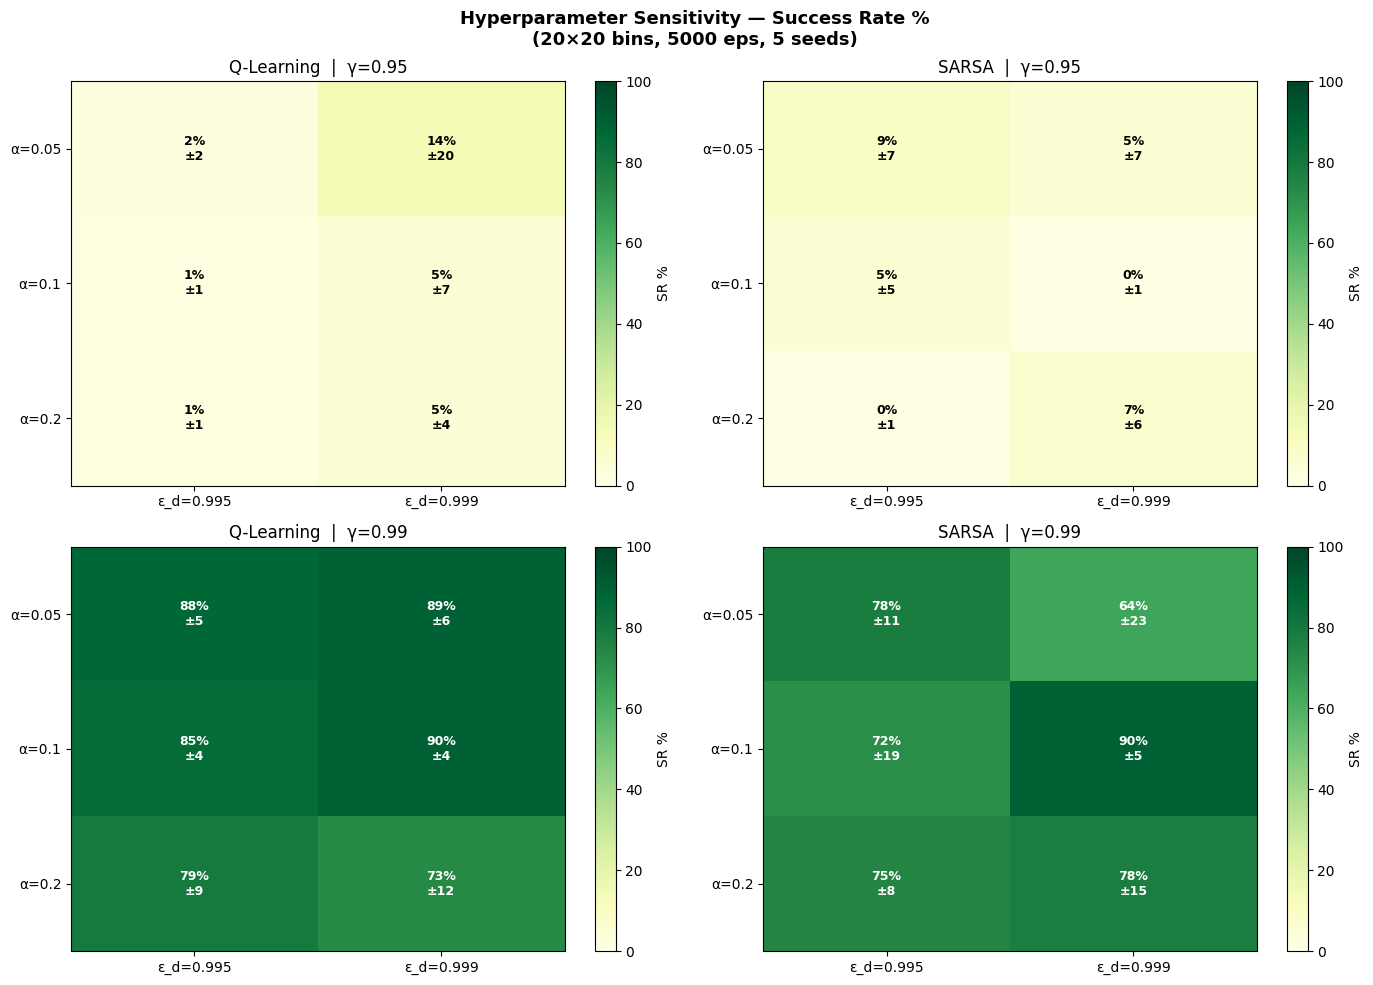

Saved: phase4_hyperparam_heatmap.png


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, method in enumerate(HP_METHODS):
    for row, gamma in enumerate(HP_GAMMAS):
        ax   = axes[row, col]
        grid = np.zeros((len(HP_ALPHAS), len(HP_EDECAYS)))
        gstd = np.zeros_like(grid)

        for i, alpha in enumerate(HP_ALPHAS):
            for j, edecay in enumerate(HP_EDECAYS):
                v = hp_results[method][(alpha, gamma, edecay)]
                grid[i, j] = v["mean"]
                gstd[i, j] = v["std"]

        im = ax.imshow(grid, cmap="YlGn", vmin=0, vmax=100, aspect="auto")
        plt.colorbar(im, ax=ax, label="SR %")
        ax.set_xticks(range(len(HP_EDECAYS)))
        ax.set_xticklabels([f"ε_d={e}" for e in HP_EDECAYS])
        ax.set_yticks(range(len(HP_ALPHAS)))
        ax.set_yticklabels([f"α={a}" for a in HP_ALPHAS])
        ax.set_title(f"{method}  |  γ={gamma}", fontsize=12)

        for i in range(len(HP_ALPHAS)):
            for j in range(len(HP_EDECAYS)):
                ax.text(j, i, f"{grid[i,j]:.0f}%\n±{gstd[i,j]:.0f}",
                        ha="center", va="center", fontsize=9, fontweight="bold",
                        color="white" if grid[i, j] > 60 else "black")

plt.suptitle(f"Hyperparameter Sensitivity — Success Rate %\n"
             f"({N_BINS}×{N_BINS} bins, {HP_EPISODES} eps, {HP_SEEDS} seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase4_hyperparam_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase4_hyperparam_heatmap.png")


### Best Configuration per Method


In [54]:
print("BEST HYPERPARAMETER CONFIGURATIONS")
print("=" * 70)
for method in HP_METHODS:
    best_cfg = max(hp_results[method], key=lambda k: hp_results[method][k]["mean"])
    v        = hp_results[method][best_cfg]
    alpha, gamma, edecay = best_cfg
    print(f"  {method:12s}:  α={alpha}  γ={gamma}  ε_decay={edecay}"
          f"  →  SR = {v['mean']:.1f}% ± {v['std']:.1f}%")

print()
for method in HP_METHODS:
    ranked = sorted(hp_results[method].items(), key=lambda x: x[1]["mean"], reverse=True)
    print(f"{method} — top 3 configs:")
    for (alpha, gamma, edecay), v in ranked[:3]:
        print(f"  α={alpha}  γ={gamma}  ε_decay={edecay}  "
              f"SR={v['mean']:.1f}% ± {v['std']:.1f}%")
    print()
print("=" * 70)


BEST HYPERPARAMETER CONFIGURATIONS
  Q-Learning  :  α=0.1  γ=0.99  ε_decay=0.999  →  SR = 89.9% ± 3.7%
  SARSA       :  α=0.1  γ=0.99  ε_decay=0.999  →  SR = 89.8% ± 4.6%

Q-Learning — top 3 configs:
  α=0.1  γ=0.99  ε_decay=0.999  SR=89.9% ± 3.7%
  α=0.05  γ=0.99  ε_decay=0.999  SR=89.3% ± 6.4%
  α=0.05  γ=0.99  ε_decay=0.995  SR=87.7% ± 5.3%

SARSA — top 3 configs:
  α=0.1  γ=0.99  ε_decay=0.999  SR=89.8% ± 4.6%
  α=0.05  γ=0.99  ε_decay=0.995  SR=77.9% ± 10.8%
  α=0.2  γ=0.99  ε_decay=0.999  SR=77.5% ± 14.6%



## Part 3 — Hyperparameter Sensitivity for MC Methods

Same grid as Part 2, applied to Every-Visit MC and First-Visit MC.
Results are included for completeness even if success rate stays at 0% —
the table still reveals whether any configuration nudges learning, and the
heatmap makes the flatness explicit so it can be discussed in the conclusions.


In [55]:
HP_MC_METHODS = ["MC Every-Visit", "MC First-Visit"]

hp_mc_results = {m: {} for m in HP_MC_METHODS}
total_mc      = len(HP_ALPHAS) * len(HP_GAMMAS) * len(HP_EDECAYS) * len(HP_MC_METHODS) * HP_SEEDS
done_mc       = 0

print(f"MC Grid: {len(HP_ALPHAS)}α × {len(HP_GAMMAS)}γ × {len(HP_EDECAYS)}ε_d "
      f"× {len(HP_MC_METHODS)} methods × {HP_SEEDS} seeds = {total_mc} runs\n")

for alpha, gamma, edecay in iterproduct(HP_ALPHAS, HP_GAMMAS, HP_EDECAYS):
    cfg = (alpha, gamma, edecay)
    for method in HP_MC_METHODS:
        seed_srs = []
        for seed in range(HP_SEEDS):
            env   = create_env("discrete", "min_steps", seed=seed)
            klass = MonteCarloEveryVisit if method == "MC Every-Visit" else MonteCarloFirstVisit
            agent = klass(n_pos_bins=N_BINS, n_vel_bins=N_BINS,
                          alpha=alpha, gamma=gamma,
                          epsilon_decay=edecay, epsilon_min=EPSILON_MIN)
            _, succs, _ = train_mc(agent, env, n_episodes=HP_EPISODES, seed=seed)
            env.close()
            seed_srs.append(np.mean(succs[-200:]) * 100)
            done_mc += 1
        hp_mc_results[method][cfg] = {"mean": np.mean(seed_srs), "std": np.std(seed_srs)}

    if done_mc % (len(HP_MC_METHODS) * HP_SEEDS * 3) == 0 or done_mc == total_mc:
        print(f"  {done_mc}/{total_mc} runs complete...")

print(f"\n✓ MC hyperparameter grid complete")


MC Grid: 3α × 2γ × 2ε_d × 2 methods × 5 seeds = 120 runs

  30/120 runs complete...
  60/120 runs complete...
  90/120 runs complete...
  120/120 runs complete...

✓ MC hyperparameter grid complete


### MC Hyperparameter Heatmaps

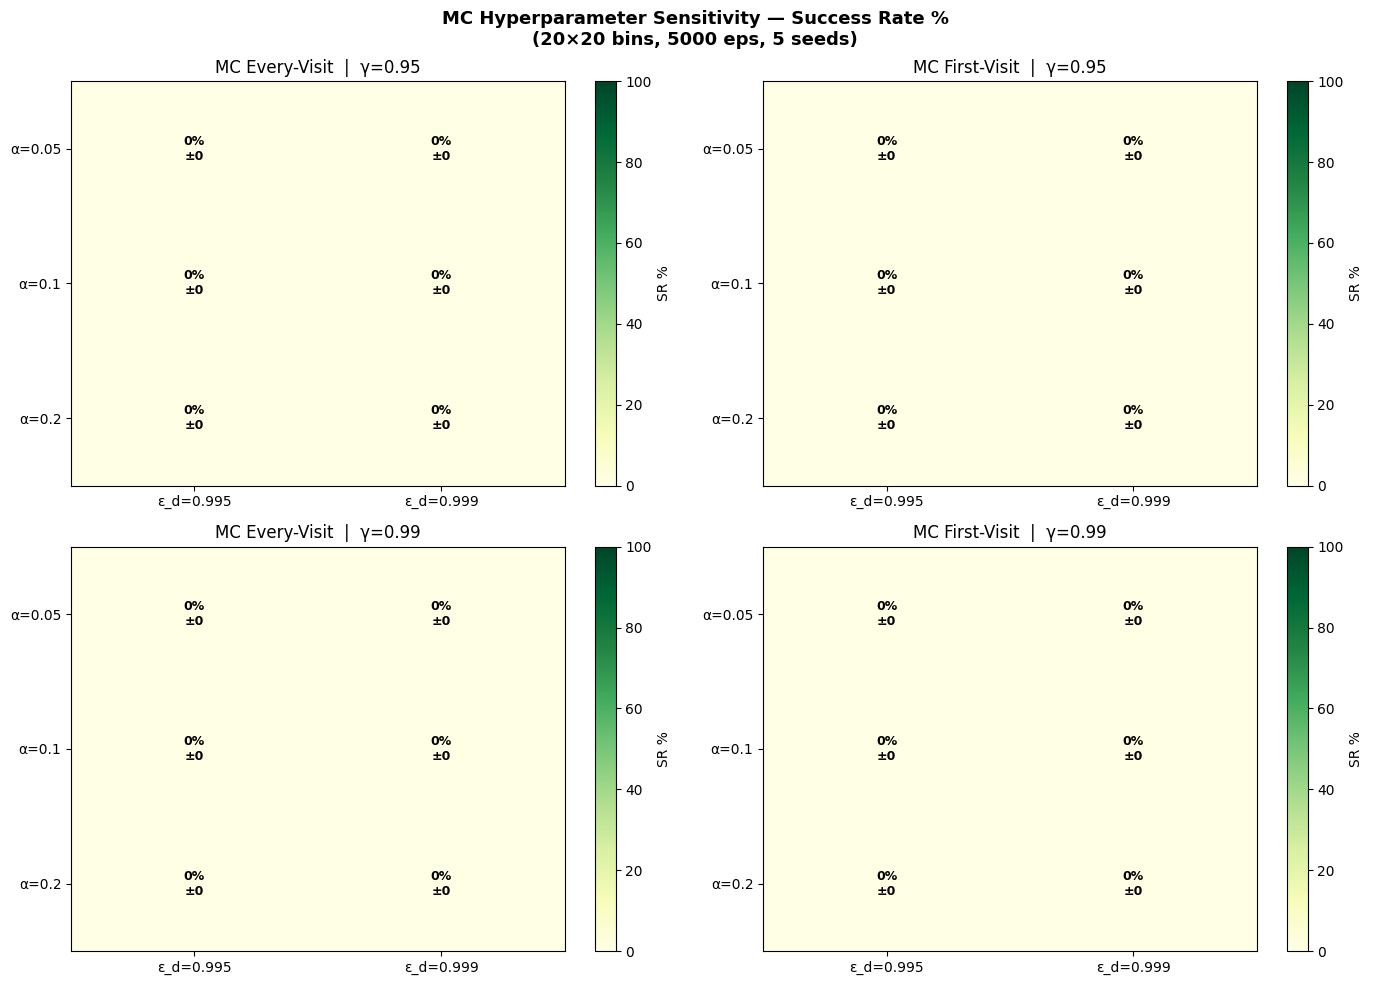

Saved: phase4_hyperparam_heatmap_mc.png


In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, method in enumerate(HP_MC_METHODS):
    for row, gamma in enumerate(HP_GAMMAS):
        ax   = axes[row, col]
        grid = np.zeros((len(HP_ALPHAS), len(HP_EDECAYS)))
        gstd = np.zeros_like(grid)

        for i, alpha in enumerate(HP_ALPHAS):
            for j, edecay in enumerate(HP_EDECAYS):
                v = hp_mc_results[method][(alpha, gamma, edecay)]
                grid[i, j] = v["mean"]
                gstd[i, j] = v["std"]

        im = ax.imshow(grid, cmap="YlGn", vmin=0, vmax=100, aspect="auto")
        plt.colorbar(im, ax=ax, label="SR %")
        ax.set_xticks(range(len(HP_EDECAYS)))
        ax.set_xticklabels([f"ε_d={e}" for e in HP_EDECAYS])
        ax.set_yticks(range(len(HP_ALPHAS)))
        ax.set_yticklabels([f"α={a}" for a in HP_ALPHAS])
        ax.set_title(f"{method}  |  γ={gamma}", fontsize=12)

        for i in range(len(HP_ALPHAS)):
            for j in range(len(HP_EDECAYS)):
                ax.text(j, i, f"{grid[i,j]:.0f}%\n±{gstd[i,j]:.0f}",
                        ha="center", va="center", fontsize=9, fontweight="bold",
                        color="white" if grid[i, j] > 60 else "black")

plt.suptitle(f"MC Hyperparameter Sensitivity — Success Rate %\n"
             f"({N_BINS}×{N_BINS} bins, {HP_EPISODES} eps, {HP_SEEDS} seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase4_hyperparam_heatmap_mc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase4_hyperparam_heatmap_mc.png")


### Best MC Configuration


In [57]:
print("BEST HYPERPARAMETER CONFIGURATIONS — MC METHODS")
print("=" * 70)
for method in HP_MC_METHODS:
    best_cfg = max(hp_mc_results[method], key=lambda k: hp_mc_results[method][k]["mean"])
    v        = hp_mc_results[method][best_cfg]
    alpha, gamma, edecay = best_cfg
    print(f"  {method:16s}:  α={alpha}  γ={gamma}  ε_decay={edecay}"
          f"  →  SR = {v['mean']:.1f}% ± {v['std']:.1f}%")

print()
for method in HP_MC_METHODS:
    ranked = sorted(hp_mc_results[method].items(),
                    key=lambda x: x[1]["mean"], reverse=True)
    print(f"{method} — top 3 configs:")
    for (alpha, gamma, edecay), v in ranked[:3]:
        print(f"  α={alpha}  γ={gamma}  ε_decay={edecay}  "
              f"SR={v['mean']:.1f}% ± {v['std']:.1f}%")
    print()
print("=" * 70)


BEST HYPERPARAMETER CONFIGURATIONS — MC METHODS
  MC Every-Visit  :  α=0.05  γ=0.95  ε_decay=0.995  →  SR = 0.0% ± 0.0%
  MC First-Visit  :  α=0.05  γ=0.95  ε_decay=0.995  →  SR = 0.0% ± 0.0%

MC Every-Visit — top 3 configs:
  α=0.05  γ=0.95  ε_decay=0.995  SR=0.0% ± 0.0%
  α=0.05  γ=0.95  ε_decay=0.999  SR=0.0% ± 0.0%
  α=0.05  γ=0.99  ε_decay=0.995  SR=0.0% ± 0.0%

MC First-Visit — top 3 configs:
  α=0.05  γ=0.95  ε_decay=0.995  SR=0.0% ± 0.0%
  α=0.05  γ=0.95  ε_decay=0.999  SR=0.0% ± 0.0%
  α=0.05  γ=0.99  ε_decay=0.995  SR=0.0% ± 0.0%



## Phase 4 — Conclusions

### Baselines

| Method | Success Rate | Avg Steps | Avg Reward |  Stability |
|---|---|---|---|---|
| **Q-Learning** | **85.3% ± 4.3%** | 167.6 ± 4.5 | −167.6 ± 4.5 | 0.363 |
| SARSA | 71.8% ± 18.6% | 175.4 ± 4.8 | −175.4 ± 4.8 | 0.128 |
| MC Every-Visit | 0.0% ± 0.0% | 200.0 ± 0.0 | −200.0 ± 0.0 | 0.000 |
| MC First-Visit | 0.0% ± 0.0% | 200.0 ± 0.0 | −200.0 ± 0.0 | 0.000 |

---

### Finding 1 — Q-Learning is the most reliable TD method

Q-Learning achieved **85.3% SR with only ±4.3% variance** across 5 seeds —
consistent performance in the range 81–94% regardless of random initialization.
SARSA achieved a lower mean (71.8%) and far higher variance (±18.6%), with
per-seed results of 83%, 68%, 73%, **13%**, 98%.

The 13% collapse on seed 4 reveals the key weakness of on-policy learning:
SARSA bootstraps from the action the exploratory policy *actually takes*,
which under an unlucky seed kept the agent in a bad corner of the Q-table.
Q-Learning bootstraps from `max_a Q(s', a)` regardless of the exploration
action — it always targets the best known value, decoupling the learning
target from the exploratory behaviour.

---

### Finding 2 — Monte Carlo completely failed under all conditions

Both MC variants achieved **0.0% SR across every seed, every episode, and every
hyperparameter configuration** (12 configs × 5 seeds each = 60 runs each, all 0%).
This is a structural failure caused by the interaction of three Mountain Car
properties:

1. **Sparse terminal reward**: The only reward signal distinguishing a good
   trajectory from a bad one arrives at the goal — which is never reached.
   Every episode ends by truncation at 200 steps with identical total return
   (≈ −200). There is no gradient for the Q-table to follow.

2. **No bootstrapping**: TD methods receive a useful update at every timestep —
   even a failed episode moves Q-values slightly for states visited near high-value
   regions (via the max Q(s') term). MC accumulates no update until the episode
   terminates, and when it terminates with the same −200 reward every time, the
   backward sweep produces updates proportional to `G_t − Q(s,a) ≈ 0` for all
   (s, a) pairs after early training anchors Q-values near −200.

3. **Discounting over long horizons**: With γ=0.99 and a 200-step episode, the
   return seen from step t is `G_t = -1 * (1 + 0.99 + ... + 0.99^(199-t))`.
   Every state in every failed episode gets a nearly identical G_t regardless of
   its physical proximity to the goal — the Q-table gets no spatial gradient.

Even the "best" MC configuration from the HP sweep (α=0.05, γ=0.95,
ε_decay=0.995) returned 0.0% ± 0.0%, confirming the failure is not a
hyperparameter issue but a fundamental algorithm–environment mismatch.

---

### Finding 3 — Hyperparameter tuning closes the gap between TD methods

The default ε_decay=0.995 reaches ε_min≈0.05 after ~580 episodes. With
ε_decay=0.999 (reaches ε_min after ~2995 episodes), both methods benefit from
prolonged exploration:

| Method | Default (ε_d=0.995) | Best HP (ε_d=0.999, α=0.1, γ=0.99) |
|---|---|---|
| Q-Learning | 85.3% ± 4.3% | **89.9% ± 3.7%** |
| SARSA | 71.8% ± 18.6% | **89.8% ± 4.6%** |

SARSA benefits far more from slower decay (+18% SR) because its on-policy nature
means that exploring longer gives it more chances to discover the goal before
committing to a greedy policy. Once both methods use the right exploration
schedule, they converge to virtually identical performance (~90%) —
suggesting the off- vs on-policy distinction matters mainly during the early
exploration phase, not at the final converged policy.

---

### Finding 4 — What the thrust rates reveal about converged policies

| Method | Thrust Rate | Interpretation |
|---|---|---|
| MC Every-Visit | 89.6% | Stuck in maximum-thrust default (Q-table unlearned) |
| SARSA | 83.4% | Aggressive but slightly more selective |
| Q-Learning | 82.0% | Learned momentum strategy |
| MC First-Visit | 66.1% | Structurally different but still 0% SR — idle bias |

MC Every-Visit's 89.6% thrust rate reflects a Q-table that never differentiated
between actions — the agent defaults to near-random exploration, which in
MountainCar tends toward the two thrust actions. MC First-Visit's 66.1% thrust
rate suggests the first-visit restriction produced an idle bias — updating
Q-values only at the temporally earliest (s,a) visit anchored values without
enough signal to learn directional thrust sequences.

---

### Physical Interpretation

TD methods work on Mountain Car because each step's update propagates
information backward: a state adjacent to a goal-reaching state accumulates
slightly higher Q-values even before it is ever part of a successful episode.
This creates a value gradient that guides exploration toward the goal region.
MC methods have no such mechanism — in a problem where the only useful
terminal reward has never been observed, the Q-table remains a flat −200
landscape with no gradient to exploit.

The practical lesson: **bootstrapping is not an approximation convenience —
it is structurally necessary when terminal success is rare and episode rewards
are otherwise uninformative.**

---

### Next Step

Phase 5 applies OFAT (One-Factor-At-a-Time) sensitivity analysis to the best
TD method (Q-Learning) to understand which hyperparameters are brittle thresholds
vs smooth knobs, and how α and γ interact.
